In [283]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error


# Load the data

In [284]:
data = pd.read_csv("Electric_Production.csv", index_col="DATE", parse_dates=True).rename(columns={"IPG2211A2N": "Total Production"})

In [285]:
data.head()

,Total Production
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [286]:
data.shape

(397, 1)

In [287]:
data.index.freq = 'MS'
data.index

DatetimeIndex(['1985-01-01', '1985-02-01', '1985-03-01', '1985-04-01',
               '1985-05-01', '1985-06-01', '1985-07-01', '1985-08-01',
               '1985-09-01', '1985-10-01',
               ...
               '2017-04-01', '2017-05-01', '2017-06-01', '2017-07-01',
               '2017-08-01', '2017-09-01', '2017-10-01', '2017-11-01',
               '2017-12-01', '2018-01-01'],
              dtype='datetime64[ns]', name='DATE', length=397, freq='MS')

In [288]:
data.isna().sum()

Total Production    0
dtype: int64

In [289]:
data.describe()

,Total Production
count,397.000000
mean,88.847218
std,15.387834
min,55.315100
25%,77.105200
50%,89.779500
75%,100.524400
max,129.404800


In [290]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 397 entries, 1985-01-01 to 2018-01-01
Freq: MS
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Total Production  397 non-null    float64
dtypes: float64(1)
memory usage: 6.2 KB


In [291]:
data.head()

,Total Production
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


### Total Energy Production Plot

<Axes: title={'center': 'Energy Production over time'}, xlabel='DATE', ylabel='Total Production'>

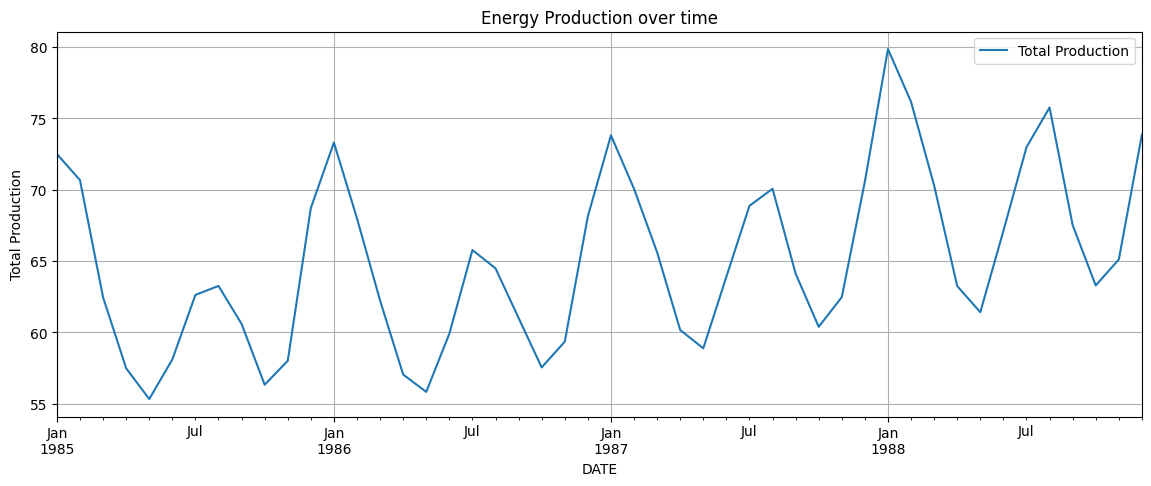

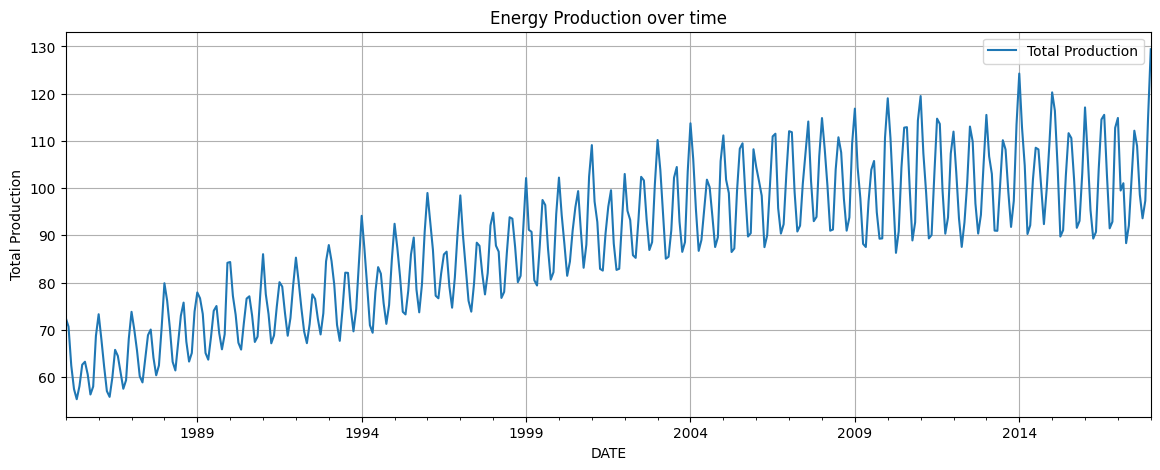

In [292]:
data.head(48).plot(figsize=(14,5), grid=True, title="Energy Production over time", ylabel="Total Production")
data.plot(figsize=(14,5), grid=True, title="Energy Production over time", ylabel="Total Production")

Observations:
- No missing data
- Data is non-linear, every Jan(Winter) there is spike
- seasonal period is 1 year

<Axes: xlabel='DATE'>

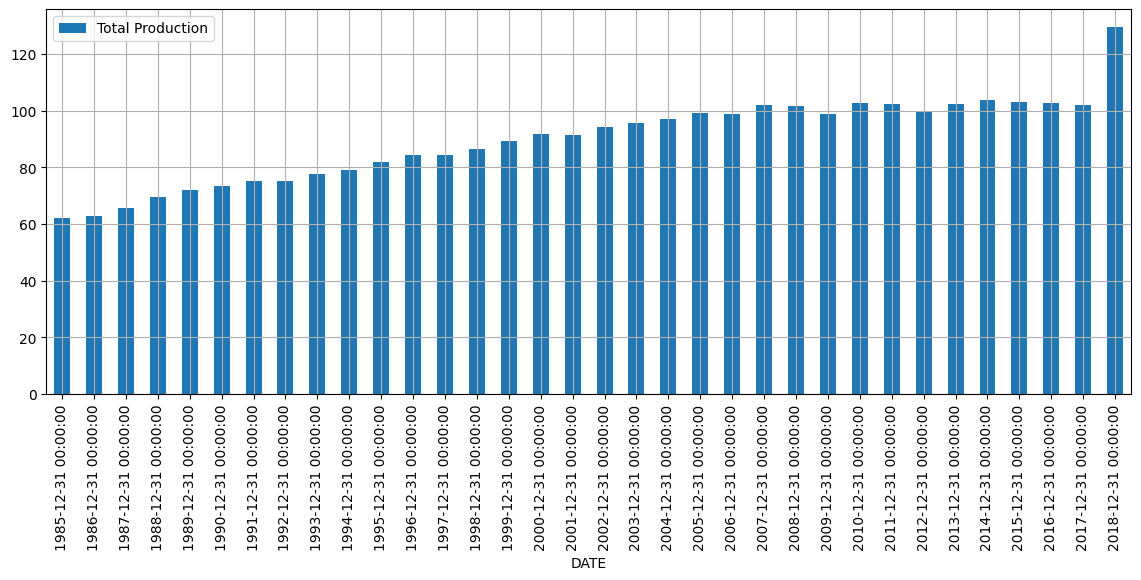

In [293]:
data.resample(rule='YE').mean().plot(kind='bar', figsize=(14,5), grid=True)


In [294]:
data["Production: 1 month delay"] = data["Total Production"].shift(1)

In [295]:
data["Change in Production"] = data["Total Production"] - data["Production: 1 month delay"]

In [296]:
data.head()

,Total Production,Production: 1 month delay,Change in Production
DATE,,,
1985-01-01,72.5052,NaN,NaN
1985-02-01,70.6720,72.5052,-1.8332
1985-03-01,62.4502,70.6720,-8.2218
1985-04-01,57.4714,62.4502,-4.9788
1985-05-01,55.3151,57.4714,-2.1563


<Axes: title={'center': 'Energy Production change by month'}, xlabel='DATE', ylabel='Total Production'>

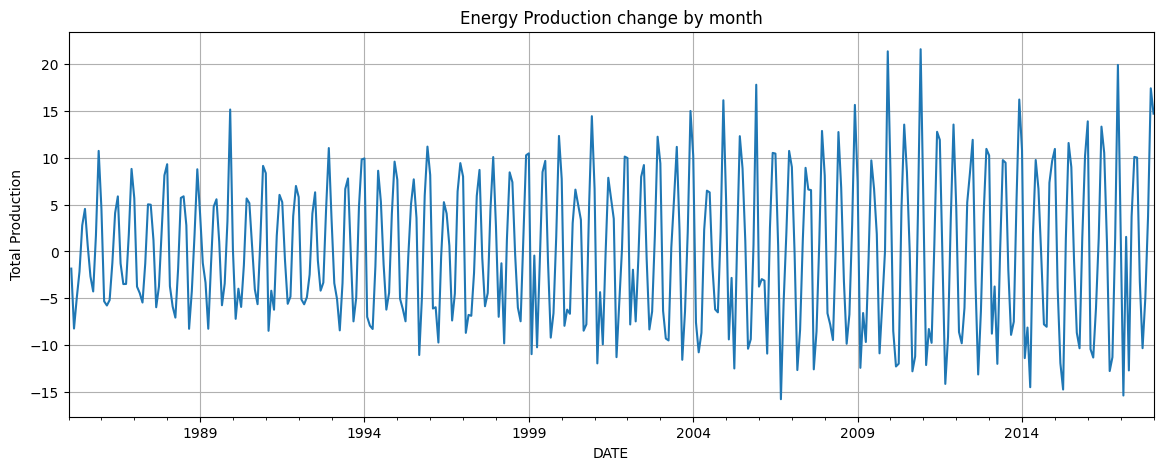

In [297]:
data["Change in Production"].plot(figsize=(14,5), grid=True, title="Energy Production change by month", ylabel="Total Production")

<Axes: xlabel='Change in Production - 1 month', ylabel='Frequency'>

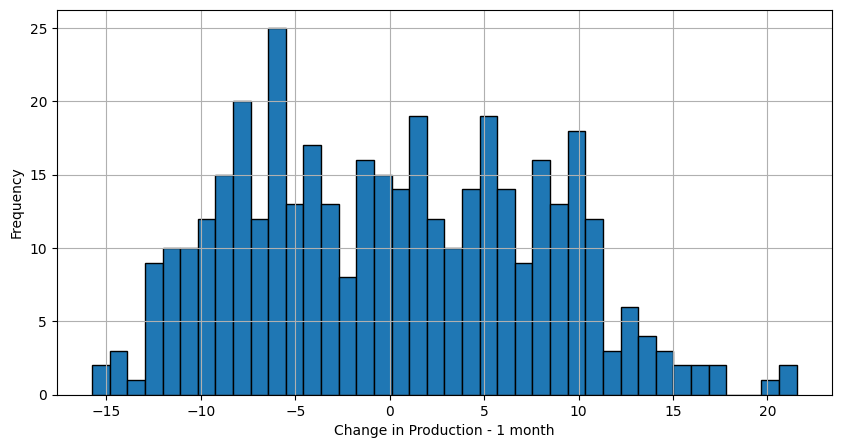

In [298]:
data["Change in Production"].plot(kind='hist', edgecolor = 'k', bins=40, figsize=(10,5), grid=True, xlabel="Change in Production - 1 month")

In [299]:
k=12
data["Production: 1 year delay"] = data["Total Production"].shift(periods=12)

In [300]:
data["Change in Production - 12 months"] = data["Total Production"] - data["Production: 1 year delay"]
data.head(24)

,Total Production,Production: 1 month delay,Change in Production,Production: 1 year delay,Change in Production - 12 months
DATE,,,,,
1985-01-01,72.5052,NaN,NaN,NaN,NaN
1985-02-01,70.6720,72.5052,-1.8332,NaN,NaN
1985-03-01,62.4502,70.6720,-8.2218,NaN,NaN
1985-04-01,57.4714,62.4502,-4.9788,NaN,NaN
1985-05-01,55.3151,57.4714,-2.1563,NaN,NaN
1985-06-01,58.0904,55.3151,2.7753,NaN,NaN
1985-07-01,62.6202,58.0904,4.5298,NaN,NaN
1985-08-01,63.2485,62.6202,0.6283,NaN,NaN
1985-09-01,60.5846,63.2485,-2.6639,NaN,NaN


<Axes: title={'center': 'Energy Production change by Year'}, xlabel='DATE', ylabel='Total Production'>

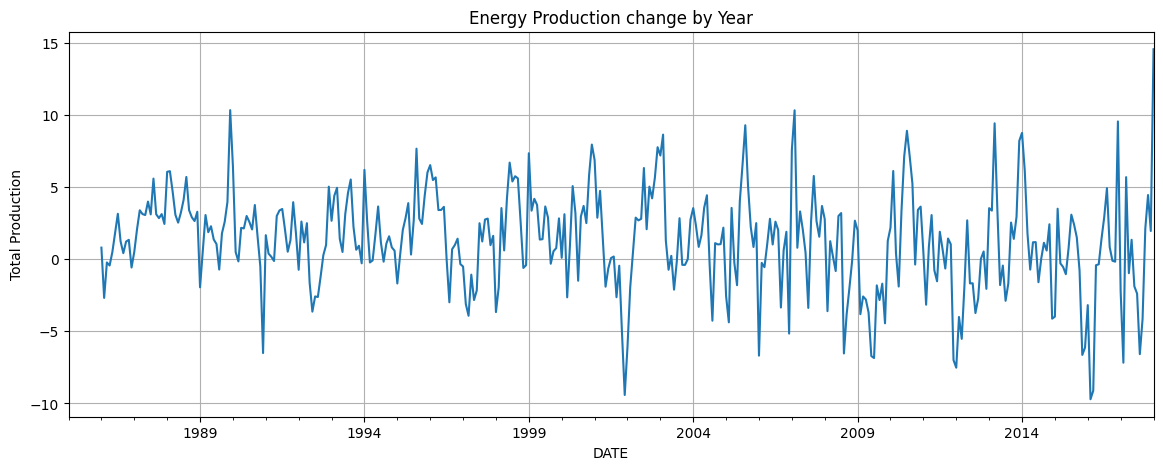

In [301]:
data["Change in Production - 12 months"].plot(figsize=(14,5), grid=True, title="Energy Production change by Year", ylabel="Total Production")

<Axes: xlabel='Change in Production - 12 months', ylabel='Frequency'>

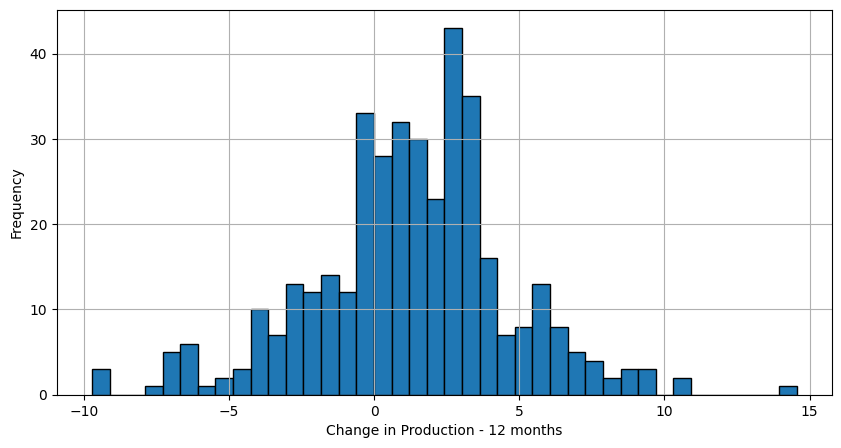

In [302]:
data["Change in Production - 12 months"].plot(kind='hist', edgecolor = 'k', bins=40, figsize=(10,5), grid=True, xlabel="Change in Production - 12 months")

### check for stationarity - Dickey-Fuller (ADF) test


Null Hypothesis: Data is not stationary
Alternate Hypothesis : Data is stationary

In [303]:
from statsmodels.tsa.statespace.tools import diff
from statsmodels.tsa.stattools import adfuller

result = adfuller(data["Total Production"].dropna())
labels = ["Test Statistics", "p-value", "used lags", "No of Observations", "Critical Value", "icbest"]
for key, val in enumerate(result):
    print(f"{labels[key]}: {val}")

if result[1] < 0.05:
    print("Reject the null hypothesis")
    print("Data is stationary")
else:
    print("Failed to reject the hypothesis")
    print("Data is not stationary")


Test Statistics: -2.2569903500472392
p-value: 0.18621469116586947
used lags: 15
No of Observations: 381
Critical Value: {'1%': np.float64(-3.4476305904172904), '5%': np.float64(-2.869155980820355), '10%': np.float64(-2.570827146203181)}
icbest: 1840.8474501627156
Failed to reject the hypothesis
Data is not stationary


In [304]:
data["d1"] = diff(data["Total Production"], k_diff=1)

result = adfuller(data["d1"].dropna())
labels = ["Test Statistics", "p-value", "used lags", "No of Observations", "Critical Value", "icbest"]
for key, val in enumerate(result):
    print(f"{labels[key]}: {val}")

if result[1] < 0.05:
    print("Reject the null hypothesis")
    print("Data is stationary")
else:
    print("Failed to reject the hypothesis")
    print("Data is not stationary")


Test Statistics: -7.104890882267346
p-value: 4.077786565538609e-10
used lags: 14
No of Observations: 381
Critical Value: {'1%': np.float64(-3.4476305904172904), '5%': np.float64(-2.869155980820355), '10%': np.float64(-2.570827146203181)}
icbest: 1840.5415092614141
Reject the null hypothesis
Data is stationary


The ADF test was used to check stationarity, as per above result the original data is not statioanry but first order differencing data is stationary.

<Axes: xlabel='DATE'>

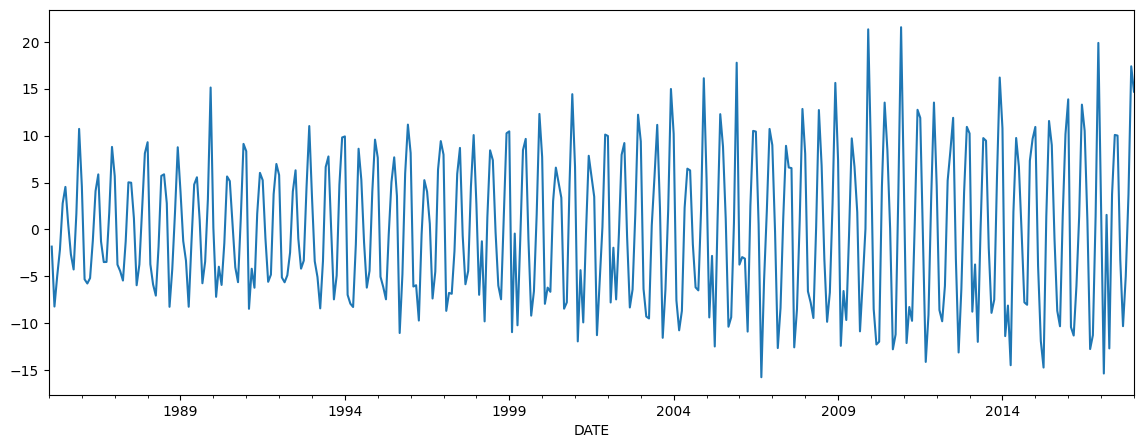

In [305]:
data["d1"].plot(figsize=(14,5))

In [306]:
data[["Total Production", "d1"]]

,Total Production,d1
DATE,,
1985-01-01,72.5052,NaN
1985-02-01,70.6720,-1.8332
1985-03-01,62.4502,-8.2218
1985-04-01,57.4714,-4.9788
1985-05-01,55.3151,-2.1563
...,...,...
2017-09-01,98.6154,-10.3158
2017-10-01,93.6137,-5.0017
2017-11-01,97.3359,3.7222


### Time Rolling - Simple moving average

In [307]:
data

,Total Production,Production: 1 month delay,Change in Production,Production: 1 year delay,Change in Production - 12 months,d1
DATE,,,,,,
1985-01-01,72.5052,NaN,NaN,NaN,NaN,NaN
1985-02-01,70.6720,72.5052,-1.8332,NaN,NaN,-1.8332
1985-03-01,62.4502,70.6720,-8.2218,NaN,NaN,-8.2218
1985-04-01,57.4714,62.4502,-4.9788,NaN,NaN,-4.9788
1985-05-01,55.3151,57.4714,-2.1563,NaN,NaN,-2.1563
...,...,...,...,...,...,...
2017-09-01,98.6154,108.9312,-10.3158,102.7637,-4.1483,-10.3158
2017-10-01,93.6137,98.6154,-5.0017,91.4867,2.1270,-5.0017
2017-11-01,97.3359,93.6137,3.7222,92.8900,4.4459,3.7222


In [308]:
data["SMA-3"] = data["Total Production"].rolling(window=3).mean()
data["SMA-6"] = data["Total Production"].rolling(window=6).mean()
data["SMA-12"] = data["Total Production"].rolling(window=12).mean()

In [309]:
data["EWMA12-false"] = data["Total Production"].ewm(span=12, adjust=False).mean()
data["EWMA12-true"] = data["Total Production"].ewm(span=12, adjust=True).mean()

<Axes: xlabel='DATE'>

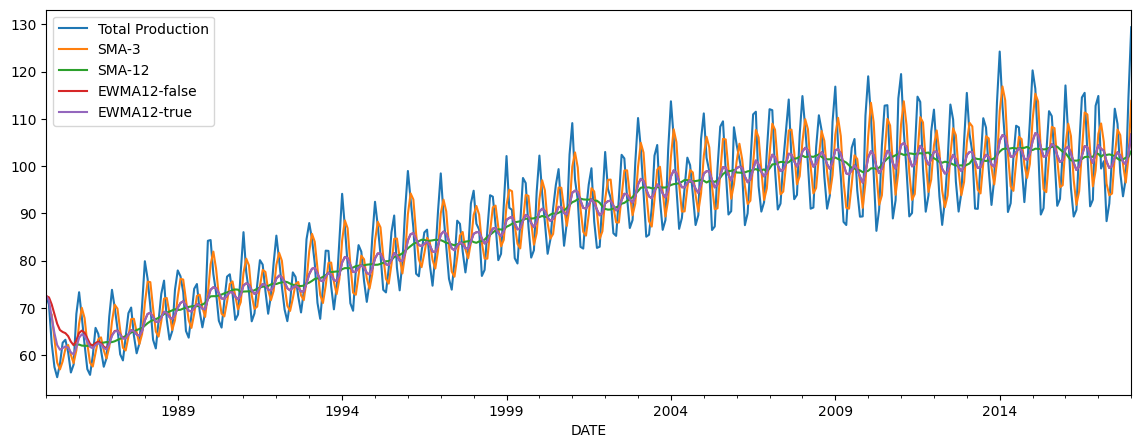

In [310]:
data[["Total Production", "SMA-3", "SMA-12", "EWMA12-false","EWMA12-true"]].plot(figsize=(14,5))

In [311]:
data[["Total Production", "SMA-3", "SMA-12", "EWMA12-false","EWMA12-true"]].head()

,Total Production,SMA-3,SMA-12,EWMA12-false,EWMA12-true
DATE,,,,,
1985-01-01,72.5052,NaN,NaN,72.505200,72.505200
1985-02-01,70.6720,NaN,NaN,72.223169,71.512217
1985-03-01,62.4502,68.542467,NaN,70.719636,67.975309
1985-04-01,57.4714,63.531200,NaN,68.681445,64.659636
1985-05-01,55.3151,58.412233,NaN,66.625085,62.120759


In [312]:
data["Total Production - expanding avg"] = data["Total Production"].expanding().mean()
data[["Total Production", "Total Production - expanding avg"]]

,Total Production,Total Production - expanding avg
DATE,,
1985-01-01,72.5052,72.505200
1985-02-01,70.6720,71.588600
1985-03-01,62.4502,68.542467
1985-04-01,57.4714,65.774700
1985-05-01,55.3151,63.682780
...,...,...
2017-09-01,98.6154,88.644452
2017-10-01,93.6137,88.657065
2017-11-01,97.3359,88.679036


<Axes: xlabel='DATE'>

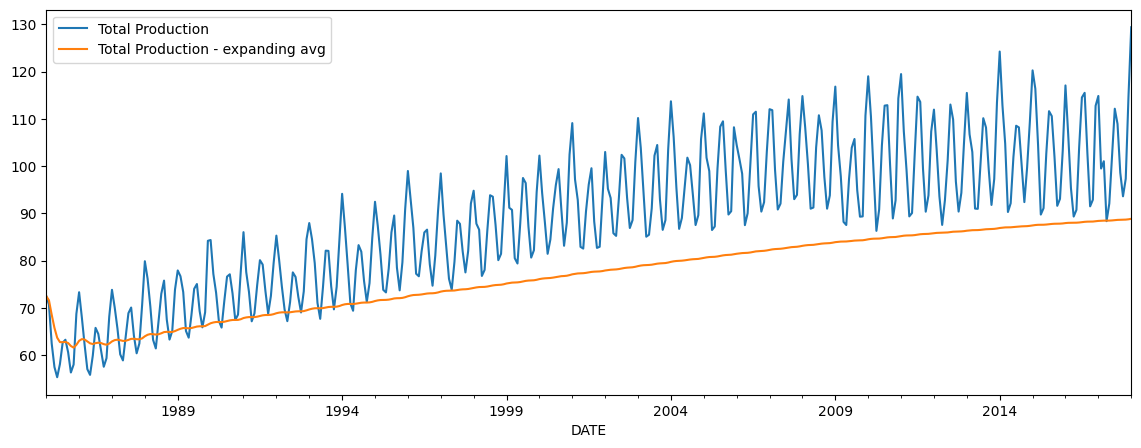

In [313]:
data[["Total Production", "Total Production - expanding avg"]].plot(figsize=(14,5))

### Decomposition

As seasonal ups and downs are larger as series level increases - using multiplicative model

In [314]:
from statsmodels.tsa.seasonal import seasonal_decompose

results_mul = seasonal_decompose(data["Total Production"], model='multiplicative')


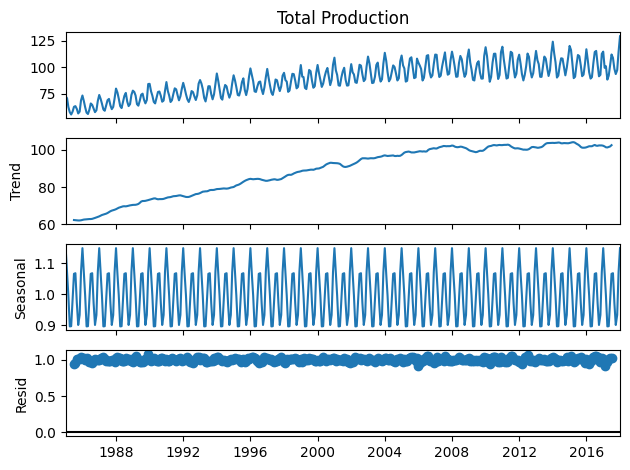

In [315]:
results_mul.plot();

<Axes: xlabel='DATE'>

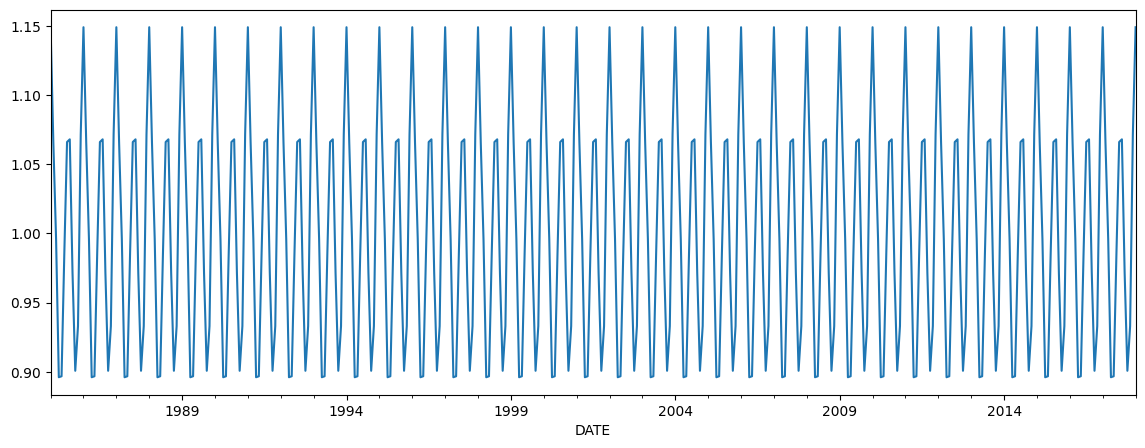

In [316]:
results_mul.seasonal.plot(figsize=(14,5))

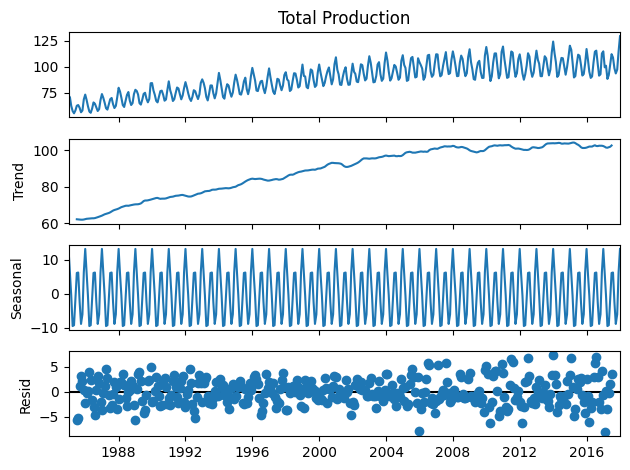

In [317]:
results_add = seasonal_decompose(data["Total Production"], model='additive')
results_add.plot();

### Holt-Winters triple exponential smoothing

In [318]:
data.shape

(397, 12)

#### train on whole dataset

In [319]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# span =12
# alpha = 2/(1+span)
model_add = ExponentialSmoothing(data["Total Production"], trend='add', seasonal='add', seasonal_periods=12).fit()
#model.params

data["TES_add_12"] = model_add.fittedvalues.shift(-1)


In [320]:
data[["Total Production", "SMA-3", "SMA-12", "EWMA12-false","EWMA12-true", "TES_add_12"]]

,Total Production,SMA-3,SMA-12,EWMA12-false,EWMA12-true,TES_add_12
DATE,,,,,,
1985-01-01,72.5052,NaN,NaN,72.505200,72.505200,68.882467
1985-02-01,70.6720,NaN,NaN,72.223169,71.512217,63.994846
1985-03-01,62.4502,68.542467,NaN,70.719636,67.975309,57.572186
1985-04-01,57.4714,63.531200,NaN,68.681445,64.659636,56.432420
1985-05-01,55.3151,58.412233,NaN,66.625085,62.120759,60.229386
...,...,...,...,...,...,...
2017-09-01,98.6154,106.566800,101.234450,102.283496,102.283496,89.491743
2017-10-01,93.6137,100.386767,101.411700,100.949681,100.949681,95.221881
2017-11-01,97.3359,96.521667,101.782192,100.393715,100.393715,111.319746


In [321]:
future_forcast_add = model_add.forecast(24)
future_forcast_add

2018-02-01    115.382983
2018-03-01    109.335559
2018-04-01     98.075984
2018-05-01    100.602133
2018-06-01    111.844469
2018-07-01    121.378628
2018-08-01    120.067352
2018-09-01    109.424084
2018-10-01    101.136883
2018-11-01    104.277809
2018-12-01    119.570126
2019-01-01    126.912424
2019-02-01    116.846441
2019-03-01    110.799018
2019-04-01     99.539442
2019-05-01    102.065592
2019-06-01    113.307928
2019-07-01    122.842086
2019-08-01    121.530810
2019-09-01    110.887543
2019-10-01    102.600342
2019-11-01    105.741268
2019-12-01    121.033585
2020-01-01    128.375882
Freq: MS, dtype: float64

In [322]:
model_mul = ExponentialSmoothing(data["Total Production"], trend='mul', seasonal='mul', seasonal_periods=12).fit()

data["TES_mul_12"] = model_mul.fittedvalues.shift(-1)

In [323]:
data[["Total Production", "TES_add_12", "TES_mul_12"]]

,Total Production,TES_add_12,TES_mul_12
DATE,,,
1985-01-01,72.5052,68.882467,67.465399
1985-02-01,70.6720,63.994846,64.979389
1985-03-01,62.4502,57.572186,56.925034
1985-04-01,57.4714,56.432420,57.609459
1985-05-01,55.3151,60.229386,61.855308
...,...,...,...
2017-09-01,98.6154,89.491743,91.650703
2017-10-01,93.6137,95.221881,96.280449
2017-11-01,97.3359,111.319746,111.794155


In [324]:
future_forcast_mul = model_mul.forecast(24)
future_forcast_mul

2018-02-01    117.786036
2018-03-01    109.976084
2018-04-01     98.899502
2018-05-01     99.454967
2018-06-01    109.684477
2018-07-01    119.182944
2018-08-01    119.408466
2018-09-01    108.274409
2018-10-01    100.277534
2018-11-01    103.866381
2018-12-01    119.731174
2019-01-01    128.736016
2019-02-01    119.383795
2019-03-01    111.467901
2019-04-01    100.241066
2019-05-01    100.804066
2019-06-01    111.172339
2019-07-01    120.799652
2019-08-01    121.028233
2019-09-01    109.743143
2019-10-01    101.637791
2019-11-01    105.275320
2019-12-01    121.355318
2020-01-01    130.482311
Freq: MS, dtype: float64

In [325]:
data

,Total Production,Production: 1 month delay,Change in Production,Production: 1 year delay,Change in Production - 12 months,d1,SMA-3,SMA-6,SMA-12,EWMA12-false,EWMA12-true,Total Production - expanding avg,TES_add_12,TES_mul_12
DATE,,,,,,,,,,,,,,
1985-01-01,72.5052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.505200,72.505200,72.505200,68.882467,67.465399
1985-02-01,70.6720,72.5052,-1.8332,NaN,NaN,-1.8332,NaN,NaN,NaN,72.223169,71.512217,71.588600,63.994846,64.979389
1985-03-01,62.4502,70.6720,-8.2218,NaN,NaN,-8.2218,68.542467,NaN,NaN,70.719636,67.975309,68.542467,57.572186,56.925034
1985-04-01,57.4714,62.4502,-4.9788,NaN,NaN,-4.9788,63.531200,NaN,NaN,68.681445,64.659636,65.774700,56.432420,57.609459
1985-05-01,55.3151,57.4714,-2.1563,NaN,NaN,-2.1563,58.412233,NaN,NaN,66.625085,62.120759,63.682780,60.229386,61.855308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-01,98.6154,108.9312,-10.3158,102.7637,-4.1483,-10.3158,106.566800,100.381183,101.234450,102.283496,102.283496,88.644452,89.491743,91.650703
2017-10-01,93.6137,98.6154,-5.0017,91.4867,2.1270,-5.0017,100.386767,101.257967,101.411700,100.949681,100.949681,88.657065,95.221881,96.280449
2017-11-01,97.3359,93.6137,3.7222,92.8900,4.4459,3.7222,96.521667,102.133867,101.782192,100.393715,100.393715,88.679036,111.319746,111.794155


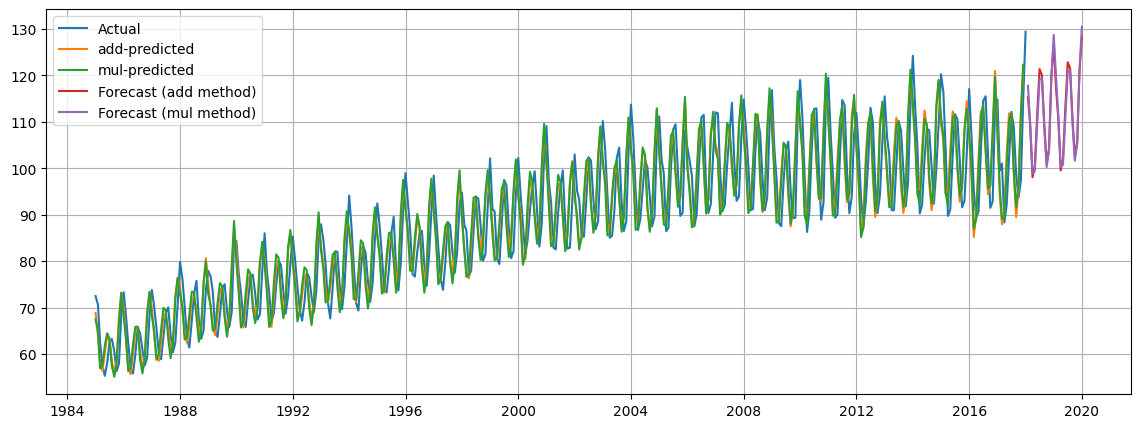

In [326]:
plt.figure(figsize=(14,5))
plt.plot(data.index, data['Total Production'], label='Actual')
plt.plot(data.index, data['TES_add_12'], label='add-predicted')
plt.plot(data.index, data['TES_mul_12'], label='mul-predicted')
plt.plot(future_forcast_add.index, future_forcast_add, label='Forecast (add method)')
plt.plot(future_forcast_mul.index, future_forcast_mul, label='Forecast (mul method)')
plt.legend()
plt.grid()

<Axes: xlabel='DATE'>

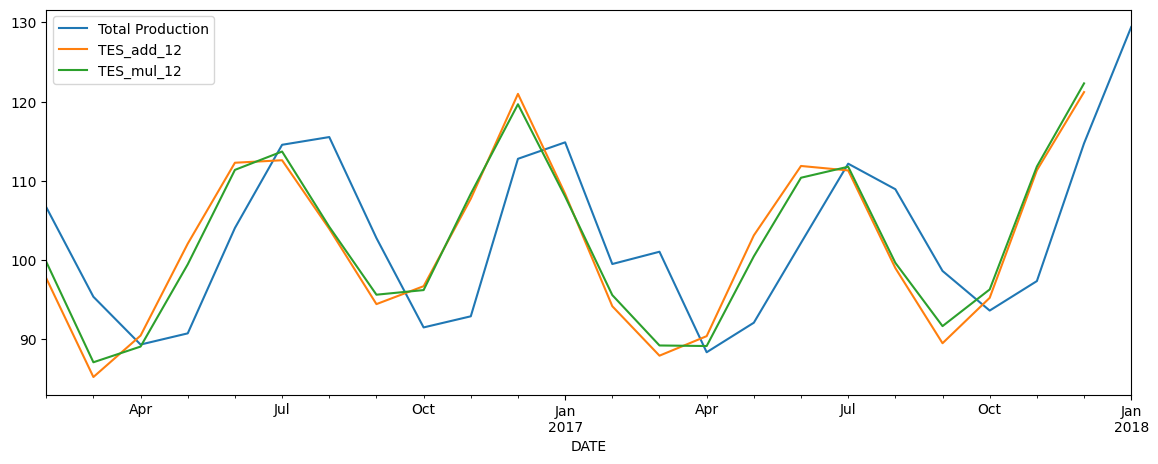

In [327]:
data[['Total Production', 'TES_add_12', 'TES_mul_12']].iloc[-24:].plot(figsize=(14,5))

In [328]:
#train test split

training_data = data[["Total Production"]].copy()
train = training_data.iloc[:-24]
test = training_data.iloc[-24:]

train.shape, test.shape



((373, 1), (24, 1))

In [329]:
model_add = ExponentialSmoothing(train["Total Production"], trend='add', seasonal='add', seasonal_periods=12).fit()
model_mul = ExponentialSmoothing(train["Total Production"], trend='mul', seasonal='mul', seasonal_periods=12).fit()

# train["Train Predicted Production(add)"] = model_add.fittedvalues.shift(-1)
# train[["Total Production", "Train Predicted Production"]].plot(figsize=(14,5), grid=True)


In [330]:
forecast_add = model_add.forecast(len(test))
forecast_mul = model_mul.forecast(len(test))


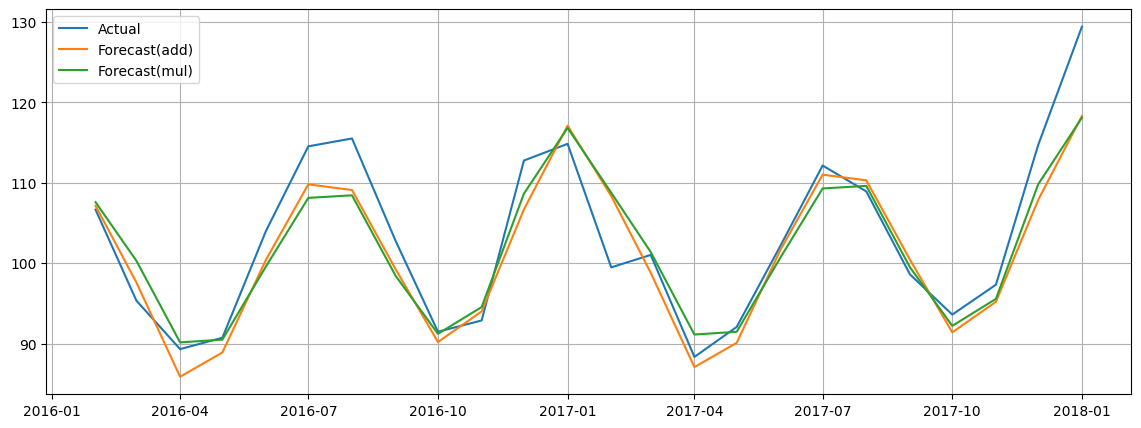

In [331]:
plt.figure(figsize=(14,5))
plt.plot(test.index, test['Total Production'], label='Actual')
plt.plot(test.index, forecast_add, label='Forecast(add)')
plt.plot(test.index, forecast_mul, label='Forecast(mul)')
plt.legend()
plt.grid()

#### Evaluation

In [332]:
def model_evaluation(df, forecast_result):
    mae = mean_absolute_error(df, forecast_result)
    mse = mean_squared_error(df, forecast_result)
    rmse = root_mean_squared_error(df, forecast_result)
    mape = mean_absolute_percentage_error(df, forecast_result)

    return {
        "Test MAE": mae,
        "MSE": mse, 
        "RMSE": rmse, 
        "MAPE": mape
    }
    #print(f"Test MAE: {mae}, MSE: {mse}, RMSE: {rmse}, MAPE: {mape}")


In [333]:
results = []

results.append({
    "Model": "Holt-Winters-Additive",
    **model_evaluation(test['Total Production'], forecast_add)
    })

results.append({
    "Model": "Holt-Winters-Multiplicative",
    **model_evaluation(test['Total Production'], forecast_mul)
    })

result_df = pd.DataFrame(results)
result_df

,Model,Test MAE,MSE,RMSE,MAPE
0,Holt-Winters-Additive,3.266477,17.872318,4.227566,0.030646
1,Holt-Winters-Multiplicative,3.144131,18.406559,4.290287,0.029237


<Axes: xlabel='DATE'>

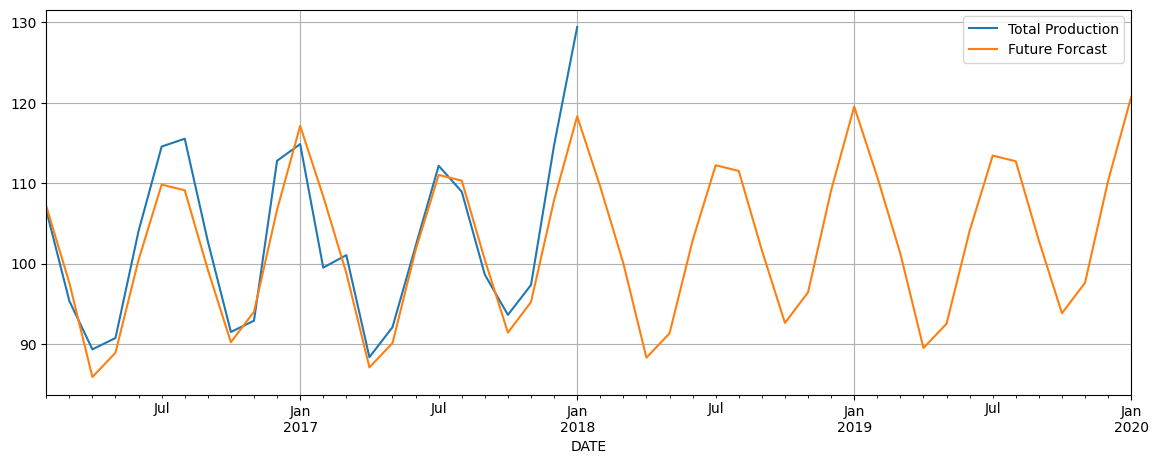

In [334]:
future_forcast = model_add.forecast(len(test)+24).rename("Future Forcast")
data["Total Production"][-24:].plot(figsize=(14,5), legend=True, grid=True)
future_forcast.plot(legend=True, grid=True)

# ACF & PACF

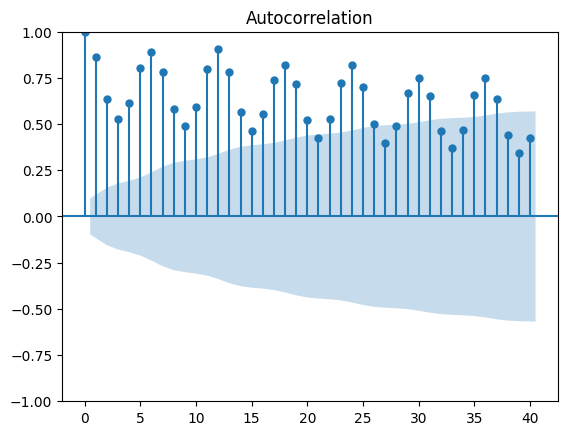

In [335]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(data["Total Production"], lags=40);

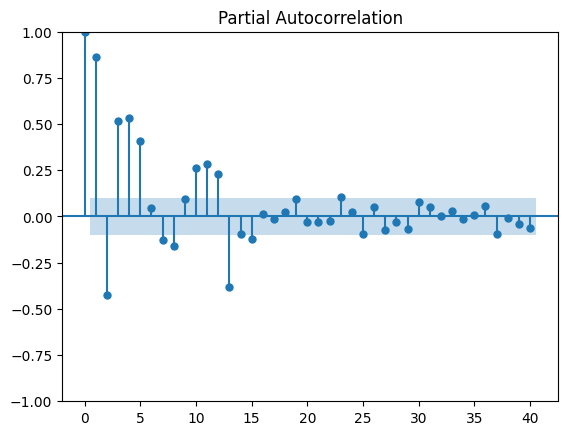

In [336]:
plot_pacf(data["Total Production"], lags=40);

# ARIMA

In [337]:
from pmdarima import auto_arima

auto_arima(data["Total Production"], seasonal=True, m=12, error_action='ignore').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  397
Model:             SARIMAX(0, 1, 4)x(2, 0, [1, 2], 12)   Log Likelihood                -923.197
Date:                                 Tue, 23 Jun 2026   AIC                           1864.394
Time:                                         09:50:17   BIC                           1900.227
Sample:                                     01-01-1985   HQIC                          1878.590
                                          - 01-01-2018                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3837      0.043     -8.998      0.000      -0.467      -0.300
ma.L2         -0.3409      0.047     -7.202      0.000      -0.434      -0.248
ma.L3         -0.0850      0.052     -1.624      0.104      -0.188       0.018
ma.L4         -0.0954      0.052     -1.826      0.068      -0.198       0.007
ar.S.L12       0.4978      0.343      1.452      0.147      -0.174       1.170
ar.S.L24       0.4961      0.340      1.459      0.145      -0.170       1.162
ma.S.L12      -0.1761      0.342     -0.515      0.606      -0.846       0.494
ma.S.L24      -0.4661      0.240     -1.940      0.052      -0.937       0.005
sigma2         5.6824      0.333     17.085      0.000       5.031       6.334
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                29.05
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               2.98   Skew:                             0.06
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Train test split

In [338]:
training_data = data[["Total Production"]].copy()
train = training_data.iloc[:-24]
test = training_data.iloc[-24:]

train.shape, test.shape

((373, 1), (24, 1))

### Train with SARIMAX

In [339]:
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(train["Total Production"], order=(0, 1, 4), seasonal_order=(2, 1, [1, 2], 12)).fit()
#model_sarimax = SARIMAX(train["Total Production"], order=(0, 1, 4), seasonal_order=(2, 0, [1, 2], 12)).fit()


In [340]:
model_sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                        Total Production   No. Observations:                  373
Model:             SARIMAX(0, 1, 4)x(2, 1, [1, 2], 12)   Log Likelihood                -804.949
Date:                                 Tue, 23 Jun 2026   AIC                           1627.899
Time:                                         09:50:18   BIC                           1662.874
Sample:                                     01-01-1985   HQIC                          1641.806
                                          - 01-01-2016                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3995      0.050     -8.009      0.000      -0.497      -0.302
ma.L2         -0.3238      0.054     -6.042      0.000      -0.429      -0.219
ma.L3         -0.1001      0.059     -1.690      0.091      -0.216       0.016
ma.L4         -0.0733      0.056     -1.302      0.193      -0.184       0.037
ar.S.L12       0.2794      0.310      0.902      0.367      -0.328       0.887
ar.S.L24      -0.2236      0.071     -3.166      0.002      -0.362      -0.085
ma.S.L12      -0.9408      0.314     -2.999      0.003      -1.556      -0.326
ma.S.L24       0.2291      0.248      0.922      0.356      -0.258       0.716
sigma2         4.9591      0.325     15.240      0.000       4.321       5.597
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                20.26
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               2.34   Skew:                            -0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [341]:
start=len(train)
end=len(train)+len(test)-1

predictions = model_sarimax.predict(start=start, end=end).rename("SARIMAX predictions")
predictions

2016-02-01    110.843011
2016-03-01    101.831684
2016-04-01     90.413839
2016-05-01     92.062991
2016-06-01    102.847503
2016-07-01    112.440993
2016-08-01    111.131460
2016-09-01    100.623792
2016-10-01     91.984237
2016-11-01     95.245289
2016-12-01    108.413708
2017-01-01    118.822025
2017-02-01    110.444988
2017-03-01    102.253086
2017-04-01     90.800820
2017-05-01     92.578961
2017-06-01    102.980183
2017-07-01    112.243488
2017-08-01    110.964608
2017-09-01    100.665825
2017-10-01     92.476247
2017-11-01     96.818649
2017-12-01    109.980575
2018-01-01    119.972394
Freq: MS, Name: SARIMAX predictions, dtype: float64

<Axes: xlabel='DATE'>

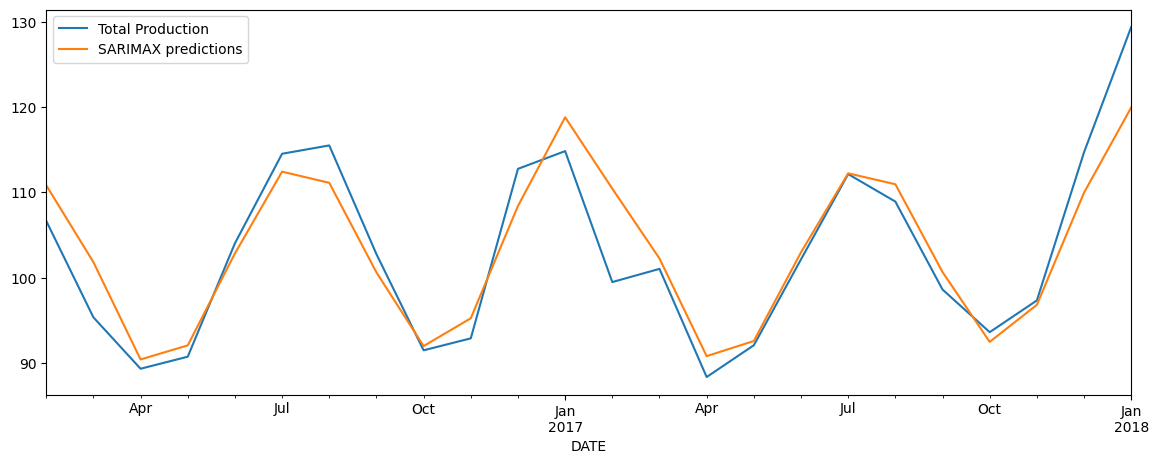

In [342]:
test.plot(figsize=(14,5), legend=True)
predictions.plot(legend = True)

### Evaluation

In [343]:
# mae = mean_absolute_error(test, predictions)
# mse = mean_squared_error(test, predictions)
# rmse = root_mean_squared_error(test, predictions)

# mape = mean_absolute_percentage_error(test, predictions)

# print(f"Test MAE: {mae}, MSE: {mse}, RMSE: {rmse}, MAPE: {mape}")
#model_evaluation(test, predictions)

results.append({
    "Model": "SARIMAX",
    **model_evaluation(test, predictions)
    })

result_df = pd.DataFrame(results)
result_df

,Model,Test MAE,MSE,RMSE,MAPE
0,Holt-Winters-Additive,3.266477,17.872318,4.227566,0.030646
1,Holt-Winters-Multiplicative,3.144131,18.406559,4.290287,0.029237
2,SARIMAX,2.916734,15.926623,3.990817,0.027569


In [344]:
test.mean()

Total Production    102.867987
dtype: float64

In [345]:
future_start = end
future_end = future_start+24
future_predictions = model_sarimax.predict(start=future_start, end=future_end).rename("SARIMAX Future Predictions")
future_predictions

2018-01-01    119.972394
2018-02-01    111.821538
2018-03-01    103.231991
2018-04-01     91.068476
2018-05-01     92.780408
2018-06-01    103.247158
2018-07-01    112.282368
2018-08-01    111.071668
2018-09-01    101.241656
2018-10-01     92.801053
2018-11-01     97.044399
2018-12-01    109.531300
2019-01-01    120.179283
2019-02-01    112.569281
2019-03-01    103.685428
2019-04-01     91.330905
2019-05-01     92.995501
2019-06-01    103.566257
2019-07-01    112.611570
2019-08-01    111.413063
2019-09-01    101.667308
2019-10-01     93.055966
2019-11-01     97.029860
2019-12-01    109.329630
2020-01-01    120.254051
Freq: MS, Name: SARIMAX Future Predictions, dtype: float64

<Axes: xlabel='DATE'>

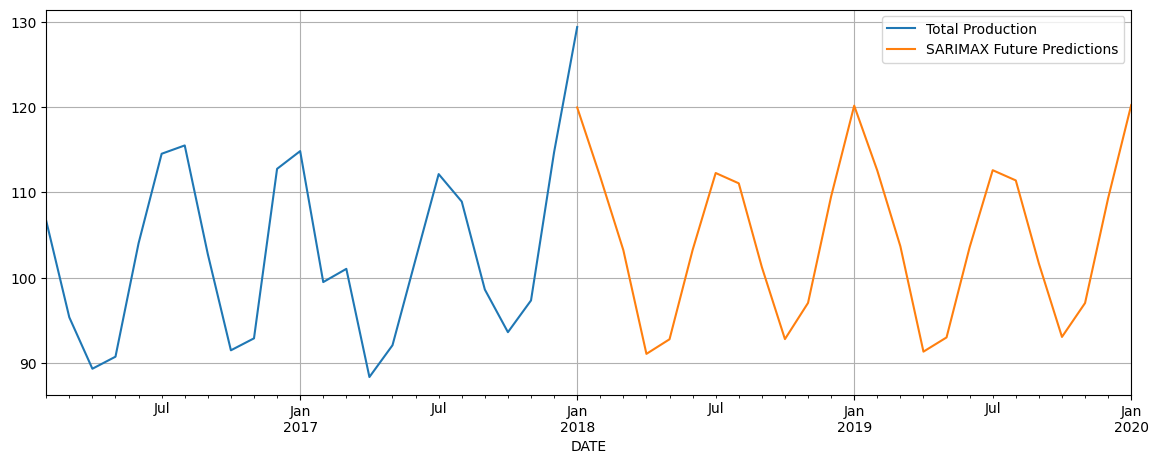

In [346]:
data["Total Production"][-24:].plot(figsize=(14,5), legend=True, grid=True)
future_predictions.plot(legend=True, grid=True)


# LSTM

In [347]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

In [348]:
data = pd.read_csv("Electric_Production.csv", index_col="DATE", parse_dates=True).rename(columns={"IPG2211A2N": "Total Production"})


In [349]:
data = data.values.astype(float)
data

array([[ 72.5052],
       [ 70.672 ],
       [ 62.4502],
       [ 57.4714],
       [ 55.3151],
       [ 58.0904],
       [ 62.6202],
       [ 63.2485],
       [ 60.5846],
       [ 56.3154],
       [ 58.0005],
       [ 68.7145],
       [ 73.3057],
       [ 67.9869],
       [ 62.2221],
       [ 57.0329],
       [ 55.8137],
       [ 59.9005],
       [ 65.7655],
       [ 64.4816],
       [ 61.0005],
       [ 57.5322],
       [ 59.3417],
       [ 68.1354],
       [ 73.8152],
       [ 70.062 ],
       [ 65.61  ],
       [ 60.1586],
       [ 58.8734],
       [ 63.8918],
       [ 68.8694],
       [ 70.0669],
       [ 64.1151],
       [ 60.3789],
       [ 62.4643],
       [ 70.5777],
       [ 79.8703],
       [ 76.1622],
       [ 70.2928],
       [ 63.2384],
       [ 61.4065],
       [ 67.1097],
       [ 72.9816],
       [ 75.7655],
       [ 67.5152],
       [ 63.2832],
       [ 65.1078],
       [ 73.8631],
       [ 77.9188],
       [ 76.6822],
       [ 73.3523],
       [ 65.1081],
       [ 63.

#### split the data

In [350]:
train = data[:-12]
test = data[-12:]

train.shape, test.shape



((385, 1), (12, 1))

In [351]:


scalar = MinMaxScaler()
train_normalized = scalar.fit_transform(train)
train_normalized[:5]

array([[0.24934943],
       [0.22275812],
       [0.10349754],
       [0.03127801],
       [0.        ]])

<Axes: >

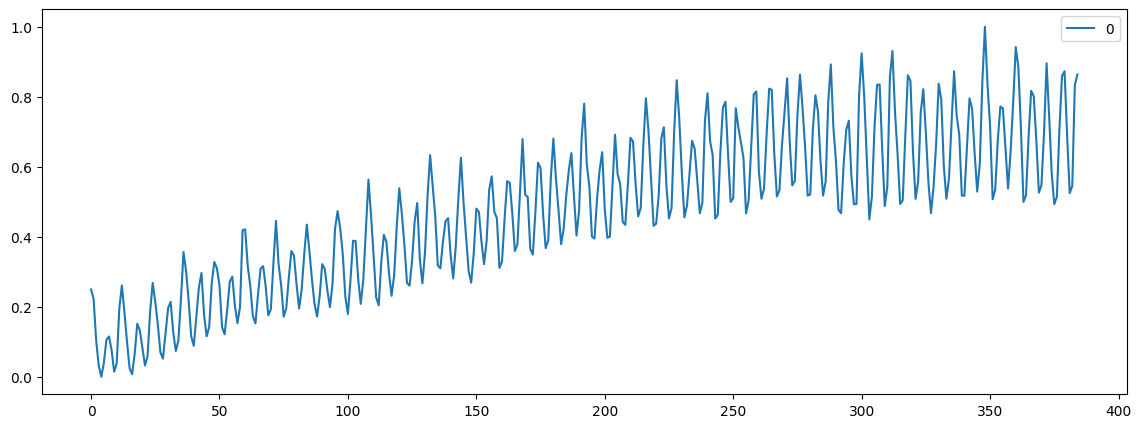

In [352]:
pd.DataFrame(train_normalized).plot(figsize=(14,5))

In [353]:
train_normalized = torch.FloatTensor(train_normalized).view(-1)
train_normalized

tensor([0.2493, 0.2228, 0.1035, 0.0313, 0.0000, 0.0403, 0.1060, 0.1151, 0.0764,
        0.0145, 0.0390, 0.1944, 0.2610, 0.1838, 0.1002, 0.0249, 0.0072, 0.0665,
        0.1516, 0.1330, 0.0825, 0.0322, 0.0584, 0.1860, 0.2684, 0.2139, 0.1493,
        0.0703, 0.0516, 0.1244, 0.1966, 0.2140, 0.1276, 0.0735, 0.1037, 0.2214,
        0.3562, 0.3024, 0.2173, 0.1149, 0.0884, 0.1711, 0.2563, 0.2966, 0.1770,
        0.1156, 0.1420, 0.2690, 0.3279, 0.3099, 0.2616, 0.1421, 0.1215, 0.1908,
        0.2715, 0.2862, 0.2029, 0.1532, 0.1995, 0.4189, 0.4213, 0.3171, 0.2594,
        0.1735, 0.1524, 0.2343, 0.3089, 0.3161, 0.2574, 0.1758, 0.1922, 0.3245,
        0.4454, 0.3226, 0.2618, 0.1717, 0.1958, 0.2833, 0.3594, 0.3459, 0.2649,
        0.1949, 0.2495, 0.3507, 0.4347, 0.3604, 0.2787, 0.2078, 0.1721, 0.2305,
        0.3219, 0.3078, 0.2472, 0.1989, 0.2638, 0.4236, 0.4733, 0.4242, 0.3504,
        0.2284, 0.1793, 0.2758, 0.3886, 0.3880, 0.2798, 0.2084, 0.2773, 0.4194,
        0.5632, 0.4619, 0.3471, 0.2272, 

In [354]:


def create_input_sequences(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        train_seq = input_data[i:i+tw]
        train_label = input_data[i+tw:i+tw+1]
        inout_seq.append((train_seq ,train_label))
    return inout_seq

In [355]:
train_window = 12
train_input_seq = create_input_sequences(train_normalized, train_window)

In [356]:
train_input_seq[:5]

[(tensor([0.2493, 0.2228, 0.1035, 0.0313, 0.0000, 0.0403, 0.1060, 0.1151, 0.0764,
          0.0145, 0.0390, 0.1944]),
  tensor([0.2610])),
 (tensor([0.2228, 0.1035, 0.0313, 0.0000, 0.0403, 0.1060, 0.1151, 0.0764, 0.0145,
          0.0390, 0.1944, 0.2610]),
  tensor([0.1838])),
 (tensor([0.1035, 0.0313, 0.0000, 0.0403, 0.1060, 0.1151, 0.0764, 0.0145, 0.0390,
          0.1944, 0.2610, 0.1838]),
  tensor([0.1002])),
 (tensor([0.0313, 0.0000, 0.0403, 0.1060, 0.1151, 0.0764, 0.0145, 0.0390, 0.1944,
          0.2610, 0.1838, 0.1002]),
  tensor([0.0249])),
 (tensor([0.0000, 0.0403, 0.1060, 0.1151, 0.0764, 0.0145, 0.0390, 0.1944, 0.2610,
          0.1838, 0.1002, 0.0249]),
  tensor([0.0072]))]

In [357]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size

        self.lstm = nn.LSTM(input_size, hidden_layer_size)

        self.linear = nn.Linear(hidden_layer_size, output_size)

        self.hidden_cell = (torch.zeros(1,1,self.hidden_layer_size),
                            torch.zeros(1,1,self.hidden_layer_size))

    def forward(self, input_seq):
        lstm_out, self.hidden_cell = self.lstm(input_seq.view(len(input_seq) ,1, -1), self.hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]

In [370]:
model = LSTM()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [371]:
epochs = 100

for i in range(epochs):
    for seq, labels in train_input_seq:
        optimizer.zero_grad()
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                        torch.zeros(1, 1, model.hidden_layer_size))

        y_pred = model(seq)

        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()

    if i%10 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 0.01680466
epoch:  11 loss: 0.00449388
epoch:  21 loss: 0.00403173
epoch:  31 loss: 0.00572550
epoch:  41 loss: 0.00277281
epoch:  51 loss: 0.00234575
epoch:  61 loss: 0.00221754
epoch:  71 loss: 0.00225314
epoch:  81 loss: 0.00158235
epoch:  91 loss: 0.00164932
epoch:  99 loss: 0.0019654238


In [372]:
test_normalized = scalar.transform(test)
test_normalized = torch.FloatTensor(test_normalized).view(-1)
test_normalized

tensor([0.6408, 0.6633, 0.4792, 0.5333, 0.6794, 0.8245, 0.7777, 0.6281, 0.5555,
        0.6095, 0.8617, 1.0747])

In [373]:
fut_pred = 12

test_inputs = test_normalized.tolist()
print(test_inputs)

[0.6407764554023743, 0.663252592086792, 0.47922825813293457, 0.5332971811294556, 0.6794058084487915, 0.8244686126708984, 0.777723491191864, 0.6280885934829712, 0.5555368661880493, 0.6095288991928101, 0.8617097735404968, 1.0747014284133911]


In [374]:
model.eval()

for i in range(fut_pred):
    seq = torch.FloatTensor(test_inputs)
    with torch.no_grad():
        model.hidden = (torch.zeros(1, 1, model.hidden_layer_size),
                        torch.zeros(1, 1, model.hidden_layer_size))
        test_inputs.append(model(seq).item())

In [375]:
test_inputs[fut_pred:]

[0.8663166761398315,
 0.6816251277923584,
 0.5580145716667175,
 0.6071077585220337,
 0.772627055644989,
 0.8568738698959351,
 0.8048235774040222,
 0.6681667566299438,
 0.631980299949646,
 0.7346765995025635,
 0.9011093378067017,
 0.8896188139915466]

In [376]:
actual_predictions = scalar.inverse_transform(np.array(test_inputs[-12:]).reshape(-1, 1))
print(actual_predictions)

[[115.03879839]
 [102.30619998]
 [ 93.78451297]
 [ 97.16898745]
 [108.57985469]
 [114.38781322]
 [110.79947646]
 [101.37838257]
 [ 98.88369548]
 [105.96355783]
 [117.43739753]
 [116.64524311]]


In [377]:
len(data)

397

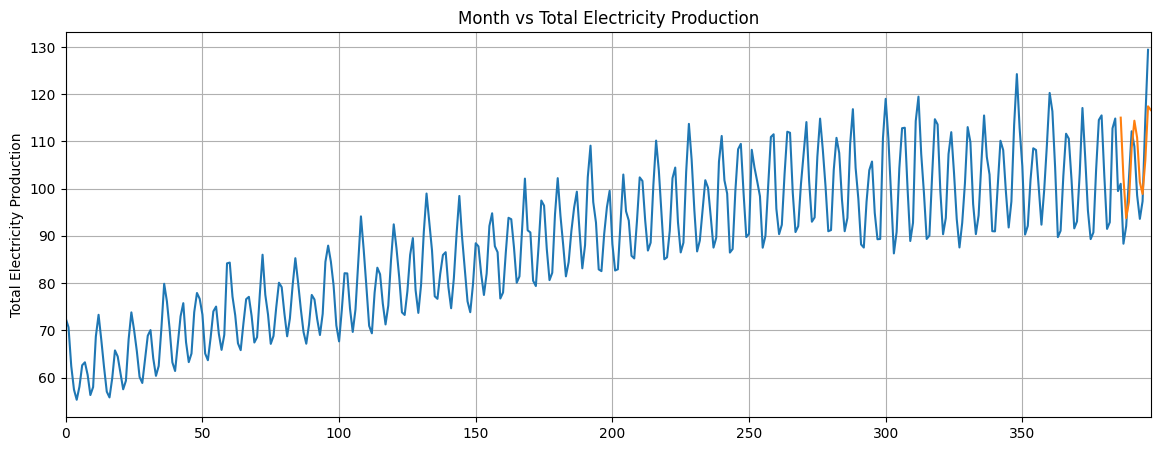

In [378]:
x = np.arange(386, 398, 1)

plt.figure(figsize=(14,5))
plt.title('Month vs Total Electricity Production')
plt.ylabel('Total Electricity Production')
plt.grid(True)

plt.autoscale(axis='x', tight=True)
plt.plot(data)
plt.plot(x,actual_predictions)
plt.show()

In [379]:
data[-13:]

array([[114.8505],
       [ 99.4901],
       [101.0396],
       [ 88.353 ],
       [ 92.0805],
       [102.1532],
       [112.1538],
       [108.9312],
       [ 98.6154],
       [ 93.6137],
       [ 97.3359],
       [114.7212],
       [129.4048]])

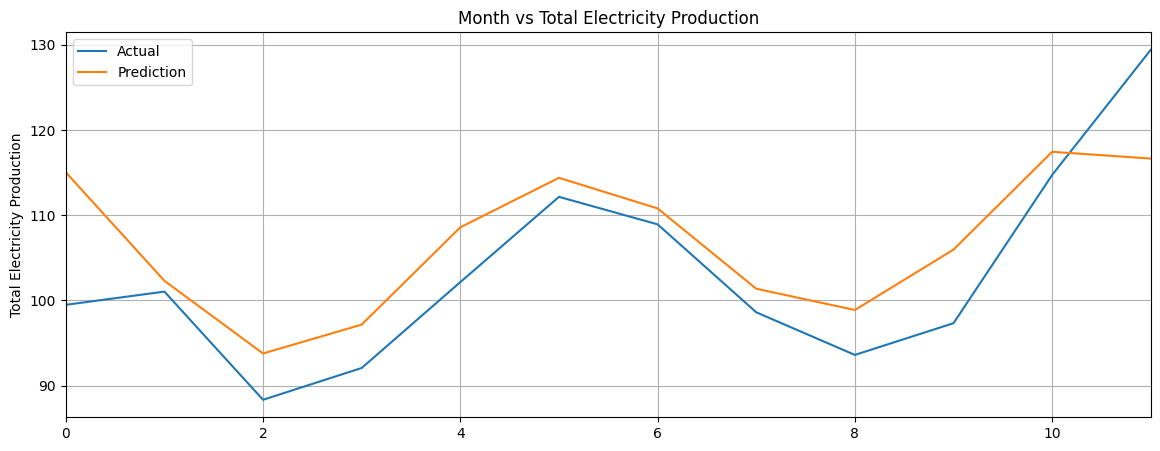

In [380]:
x = np.arange(0, 12, 1)

plt.figure(figsize=(14,5))
plt.title('Month vs Total Electricity Production')
plt.ylabel('Total Electricity Production')
plt.grid(True)

plt.autoscale(axis='x', tight=True)
plt.plot(test, label="Actual")
plt.plot(x,actual_predictions, label="Prediction")
plt.legend()
plt.show()

In [381]:

results.append({
    "Model": "LSTM",
    **model_evaluation(test, actual_predictions)
    })

result_df = pd.DataFrame(results)
result_df

,Model,Test MAE,MSE,RMSE,MAPE
0,Holt-Winters-Additive,3.266477,17.872318,4.227566,0.030646
1,Holt-Winters-Multiplicative,3.144131,18.406559,4.290287,0.029237
2,SARIMAX,2.916734,15.926623,3.990817,0.027569
3,LSTM,5.356033,58.247904,7.632031,0.049826
4,LSTM,5.833386,52.380910,7.237466,0.056731
